# Factor Analysis Demonstration In Python


## Background
- Data on national athletics records for various countries is available.

- Data Source: Applied Multivariate Statistical Analysis by Richard A. Johnson , Dean W. Wichern

- Sample size is 55 countries' athletics  records for 8  different athletics events – 100 meters to Marathon

## Objective: 
- To reduce multiple correlated athletic performance variables into a smaller set of latent factors and compute factor scores for each country to enable comparative ranking.


## Data Description

| Column Name     | Description                                      |
|-----------------|--------------------------------------------------|
| 100m_s          | Time taken to complete 100 meters (seconds)     |
| 200m_s          | Time taken to complete 200 meters (seconds)     |
| 400m_s          | Time taken to complete 400 meters (seconds)     |
| 800m_min        | Time taken to complete 800 meters (minutes)     |
| 1500m_min       | Time taken to complete 1500 meters (minutes)    |
| 5000m_min       | Time taken to complete 5000 meters (minutes)    |
| 10000m_min      | Time taken to complete 10000 meters (minutes)   |
| Marathon_min   | Time taken to complete a marathon (minutes)     |


### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer

### Load And Subset Data

In [2]:
data = pd.read_csv("Athleticsdata.csv")

# Exclude Country column for factor analysis
athletics = data.drop(columns=["Country"])
athletics.head()

,100m_s,200m_s,400m_s,800m_min,1500m_min,5000m_min,10000m_min,Marathon_min
0,10.39,20.81,46.84,1.81,3.70,14.04,29.36,137.72
1,10.31,20.06,44.84,1.74,3.57,13.28,27.66,128.30
2,10.44,20.81,46.82,1.79,3.60,13.26,27.72,135.90
3,10.34,20.68,45.04,1.73,3.60,13.22,27.45,129.95
4,10.28,20.58,45.91,1.80,3.75,14.68,30.55,146.62


###  Factor Analysis (2 factors, Varimax rotation)

In [3]:
#If this doesn't work downgrade scikit-learn to version 1.2.2 (pip install scikit-learn==1.2.2)
fa = FactorAnalyzer(
    n_factors=2,
    rotation="varimax",
    method="ml"     # Maximum Likelihood ≈ factanal()
)

fa.fit(athletics)


FactorAnalyzer(method='ml', n_factors=2, rotation='varimax', rotation_kwargs={})

### Proportion Of Explained Variance

In [8]:
ev, prop_var, cum_var = fa.get_factor_variance()

variance_df = pd.DataFrame({
    "Eigenvalue": ev,
    "Proportion_Variance": prop_var,
    "Cumulative_Variance": cum_var
}, index=[f"Factor{i+1}" for i in range(len(ev))])

variance_df


,Eigenvalue,Proportion_Variance,Cumulative_Variance
Factor1,4.071385,0.508923,0.508923
Factor2,3.267560,0.408445,0.917368


### Inference :
Two factors explain 92% of common variance. 

### Factor Loadings

In [4]:
loadings = pd.DataFrame(
    fa.loadings_,
    index=athletics.columns,
    columns=["Factor1", "Factor2"]
)

print(loadings)


               Factor1   Factor2
100m_s        0.286945  0.915753
200m_s        0.375604  0.884546
400m_s        0.537177  0.748678
800m_min      0.686320  0.627628
1500m_min     0.794815  0.535120
5000m_min     0.897772  0.400310
10000m_min    0.904061  0.405783
Marathon_min  0.912865  0.284322


### Inference :
Factor 1 represents Stamina as it shows consistently high loadings for middle-to-long distance events, while Factor 2 represents Speed with very high loadings for sprint events.

### Factor Scores (Regression method – default)

In [20]:
factor_scores = fa.transform(athletics)

data["stamina"] = factor_scores[:, 0]
data["speed"] = factor_scores[:, 1]


### Scatter plot with country labels

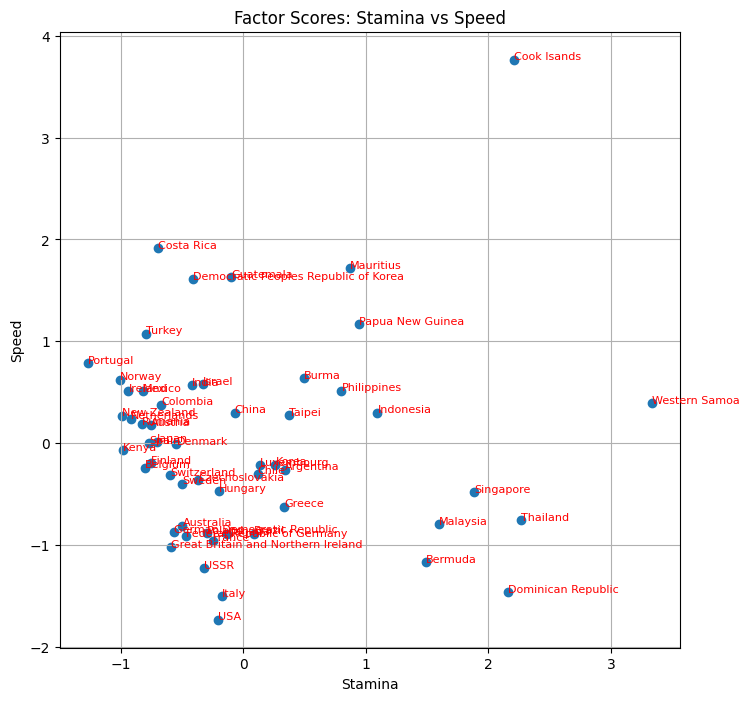

In [23]:
plt.figure(figsize=(8,8))
plt.scatter(data["stamina"], data["speed"])

for i, country in enumerate(data["Country"]):
    plt.text(
        data["stamina"].iloc[i],
        data["speed"].iloc[i],
        country,
        fontsize=8,
        color="red"
    )

plt.xlabel("Stamina")
plt.ylabel("Speed")
plt.title("Factor Scores: Stamina vs Speed")
plt.grid(True)
plt.show()
